#Neural network classification with pytorch

1. creating a classification data using sklearn dataset

In [87]:
import sklearn

In [88]:
from sklearn.datasets import make_circles
n_samples = 1000

X,y = make_circles(
    n_samples,
    noise=0.03,
    random_state=42
)


In [89]:
len(X),len(y)

(1000, 1000)

In [90]:
print(f"first 5 samples of X:\n{X[:5]}")
print(f"first 5 samples of y:\n{y[:5]}")


first 5 samples of X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of y:
[1 1 1 1 0]


In [91]:
import pandas as pd
circles = pd.DataFrame({
    "X1":X[:,0],
    "X2":X[:,1],
    "label":y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [92]:
circles.label.value_counts()

,count
label,
1,500
0,500


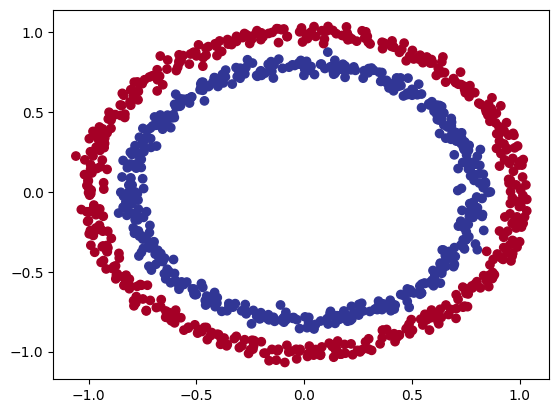

In [93]:
#visualizin usin scatter plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);

## 1.1 input and output shapes

In [94]:
X.shape , y.shape

((1000, 2), (1000,))

In [95]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [96]:
X_sample  = X[0]
y_sample =y[0]
print(f"values of one sample of X:{X_sample} and same for y :{y_sample}")
print(f"shape of one sample of X:{X_sample.shape} and same for y :{y_sample.shape}")

values of one sample of X:[0.75424625 0.23148074] and same for y :1
shape of one sample of X:(2,) and same for y :()


##turning data into tensor

In [97]:

import torch
torch.__version__

'2.10.0+cpu'

now our data is in the form of numpy first thing we need to do in pytorch is convert dataa into tensor

In [98]:
type(X), X.dtype



(numpy.ndarray, dtype('float64'))

In [99]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [100]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [101]:
type(X), X.dtype

(torch.Tensor, torch.float32)

we are converting our data from float64, which is the default data type for any tensors, to float32 because this will be taking lesser space than float64, which is the default settings.

### split data into training and test set

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)


In [103]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [104]:
n_samples


1000

##2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:

1.Setup device agonistic code so our code will run on an accelerator (GPU) if there is one

2.Construct a model (by subclassing nn.Module)

3.Define a loss function and optimizer

4.Create a training and test loop

In [105]:
device = "cpu"
device

'cpu'

In [106]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [107]:
X_train.shape

torch.Size([800, 2])

In [108]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

In [109]:
import torch
from torch import nn

import sklearn
from sklearn import datasets

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.Layer_1 = nn.Linear(in_features=2, out_features=5)
    self.Layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self,x):
    return self.Layer_2(self.Layer_1(x))

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (Layer_1): Linear(in_features=2, out_features=5, bias=True)
  (Layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [110]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


X_train: torch.Size([800, 2])
y_train: torch.Size([800])


In [111]:
#replicating using nn.sequential
model_0  = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [112]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [113]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


##setup loss function and optimizer

 for regression you might want MAE or MSE (mean absolute error or mean squared error).

For classification you might want binary cross entropy or categorical cross entropy (cross entropy).

As a reminder, the loss function measures how wrong your models predictions are.

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.

In [114]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

####lets calculate accuracy to see how well our model performs

In [115]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  accuracy = (correct/len(y_pred))*100
  return accuracy

##3. Train model

To train our model, we're going to need to build a training loop with the following steps:

1.Forward pass

2.Calculate the loss

3.Optimizer zero grad

4.Loss backward (backpropagation)

5.Optimizer step (gradient descent)

In [116]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits



tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [117]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

In [118]:
print(X_train.shape)
print(model_0)


torch.Size([800, 2])
Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)


In [119]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

## builiding a training and testing loop

In [120]:
torch.manual_seed(42)

epochs = 100  #number of epoch

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  ###training

  model_0.train()

  #1.forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #2. calculate the loss/accuracy
  loss = loss_fn(y_logits,
                 y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  #3. optimizer zero grad
  optimizer.zero_grad()

  #4.loss backward
  loss.backward()

  #5.optimizer step
  optimizer.step()

  ###testing

  model_0.eval
  with torch.inference_mode():
    #1.forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred  = torch.round(torch.sigmoid(test_logits))

    #2. calculate the loss
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    ##print what's happenin'
    if epoch %10 ==0:
      print(f"epoch:{epoch} | loss: {loss:.5f}, accuracy: {acc:.2f}% | test loss: {test_loss:.5f}, test accuracy: {test_acc:.2f}%")


epoch:0 | loss: 0.69796, accuracy: 51.88% | test loss: 0.69460, test accuracy: 57.50%
epoch:10 | loss: 0.69768, accuracy: 52.00% | test loss: 0.69438, test accuracy: 58.00%
epoch:20 | loss: 0.69742, accuracy: 52.00% | test loss: 0.69418, test accuracy: 57.50%
epoch:30 | loss: 0.69717, accuracy: 52.00% | test loss: 0.69401, test accuracy: 56.50%
epoch:40 | loss: 0.69695, accuracy: 51.62% | test loss: 0.69385, test accuracy: 56.50%
epoch:50 | loss: 0.69675, accuracy: 51.38% | test loss: 0.69370, test accuracy: 56.00%
epoch:60 | loss: 0.69656, accuracy: 51.38% | test loss: 0.69357, test accuracy: 56.00%
epoch:70 | loss: 0.69638, accuracy: 51.38% | test loss: 0.69345, test accuracy: 56.50%
epoch:80 | loss: 0.69621, accuracy: 51.25% | test loss: 0.69334, test accuracy: 56.50%
epoch:90 | loss: 0.69606, accuracy: 51.38% | test loss: 0.69324, test accuracy: 55.00%


In [121]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


now we need to visualize to look how the training and testing data scattered

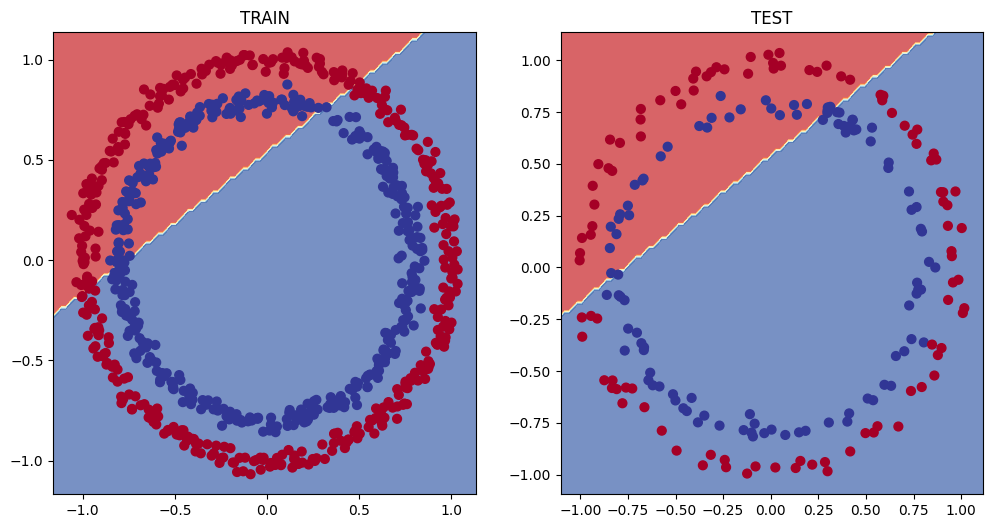

In [122]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("TRAIN")
plot_decision_boundary(model_0, X_train,
                       y_train)
plt.subplot(1, 2, 2)
plt.title("TEST")
plot_decision_boundary(model_0,X_test,y_test)


In [123]:
print(X_train.shape)
print(X_test.shape)
print(X_train[:5])

torch.Size([800, 2])
torch.Size([200, 2])
tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]])


##5. Improving a model (from a model perspective)

* Add more layers - give the model
more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.


And because these options are all values we (as machine learning engineers and data scientists) can change, they are referred as hyperparameters.

Let's try and improve our model by:

* Adding more hidden units: 5 -> 10
* Increase the number of layers: 2 -> 3
* Increase the number of epochs: 100 -> 1000

In [124]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [125]:
# create a model
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.Layer_1 = nn.Linear(in_features=2, out_features=10)
    self.Layer_2 = nn.Linear(in_features=10, out_features=10)
    self.Layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.Layer_3(self.Layer_2(self.Layer_1(x)))

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (Layer_1): Linear(in_features=2, out_features=10, bias=True)
  (Layer_2): Linear(in_features=10, out_features=10, bias=True)
  (Layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [126]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)


In [127]:
torch.manual_seed(42)

epoch = 1000

# put data in the target device
X_train,y_train =X_train.to(device), y_train.to(device)
X_test,y_test =X_test.to(device), y_test.to(device)

###TRAINING
for epoch in range(epochs):
  model_1.train()
  #forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #calculate the loss
  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  #optimizer zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  ###TESTING
  model_1.eval()
  with torch.inference_mode():
    #forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    #calculate the loss
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

  if epoch % 100 == 0:
    print(f" Epoch: {epoch} | loss: {loss:.5f} | accuracy: {acc:.2f}% | test_loss: {test_loss:.5f}, test_accuracy: {test_acc:.2f}%")




 Epoch: 0 | loss: 0.69396 | accuracy: 50.88% | test_loss: 0.69261, test_accuracy: 51.00%


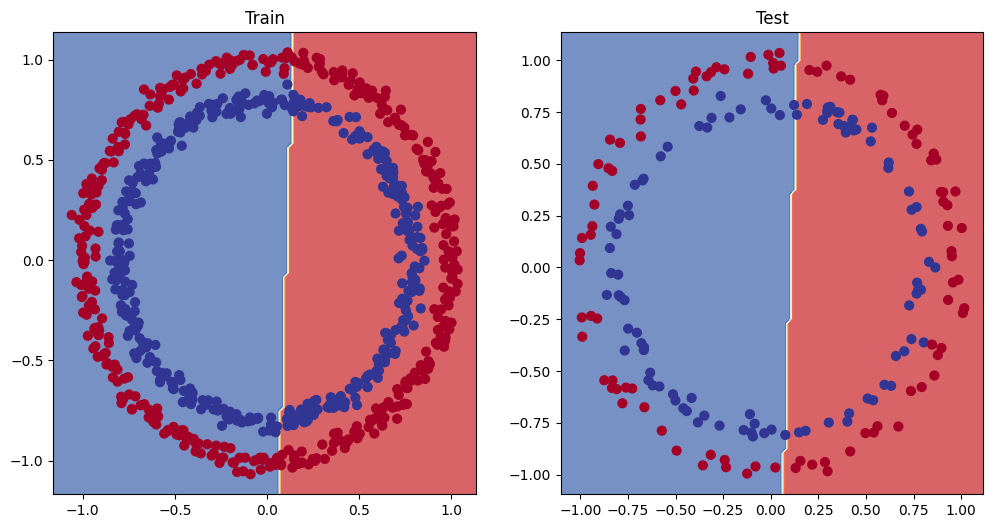

In [128]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)
plt.show()

#NON-LINEARITY

## Introducing non-linearity to the function

because non linearity helps model to classify data when its not in linear form like ours...
so to introduce non linearity we use activaton function

 **Recreating non-linear data (red and blue circles)**

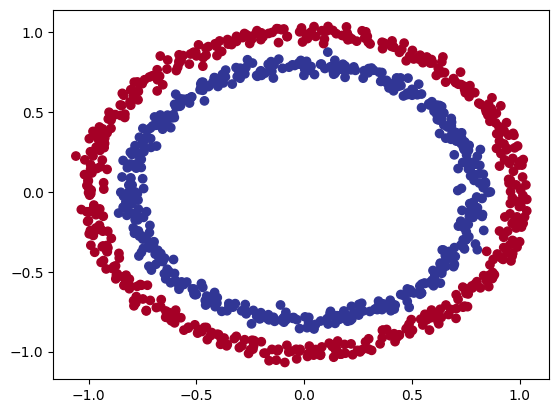

In [129]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples,
                   noise = 0.03,
                   random_state=42)
plt.scatter(X[:,0],X[:,1], c=y ,cmap=plt.cm.RdYlBu)

In [130]:
#converting data
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#creating a train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
X_train[:5], y_train[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

**Building a model with non-linearity**

* Linear = straight lines
* Non-linear = non-straight lines

Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially able to find patterns in data.

In [157]:
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.Layer_1 = nn.Linear(in_features=2, out_features=10)
    self.Layer_2 = nn.Linear(in_features=10, out_features=10)
    self.Layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()  #relu is a non linear function

  def forward(self,x):
    return (self.Layer_3(self.relu(self.Layer_2(self.relu(self.Layer_1(x))))))
model_3=CircleModelV2().to(device)
model_3

CircleModelV2(
  (Layer_1): Linear(in_features=2, out_features=10, bias=True)
  (Layer_2): Linear(in_features=10, out_features=10, bias=True)
  (Layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [158]:
#setting up loss func and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)

**trainin a model with non-linearity**

In [159]:
torch.manual_seed(42)

#putting data on target device
X_train,X_test = X_train.to(device),X_test.to(device)
y_train,y_test = y_train.to(device),y_test.to(device)

epochs = 1000

for epoch in range(epochs):
  #training
  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)
  accuracy = accuracy_fn(y_true=y_train,
                         y_pred = y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_accuracy = accuracy_fn(y_true=y_test,
                         y_pred = test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Accuracy: {accuracy:.2f}% | Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")





Epoch: 0 | Loss: 0.6929, Accuracy: 50.00% | Test Loss: 0.6931, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.6848, Accuracy: 52.88% | Test Loss: 0.6829, Test Accuracy: 57.00%
Epoch: 200 | Loss: 0.6629, Accuracy: 64.50% | Test Loss: 0.6598, Test Accuracy: 65.00%
Epoch: 300 | Loss: 0.6067, Accuracy: 78.38% | Test Loss: 0.6070, Test Accuracy: 76.50%
Epoch: 400 | Loss: 0.5002, Accuracy: 95.12% | Test Loss: 0.5136, Test Accuracy: 94.00%
Epoch: 500 | Loss: 0.3802, Accuracy: 98.88% | Test Loss: 0.4053, Test Accuracy: 98.50%
Epoch: 600 | Loss: 0.2639, Accuracy: 99.75% | Test Loss: 0.2921, Test Accuracy: 99.50%
Epoch: 700 | Loss: 0.1855, Accuracy: 99.62% | Test Loss: 0.2172, Test Accuracy: 99.50%
Epoch: 800 | Loss: 0.1356, Accuracy: 99.75% | Test Loss: 0.1658, Test Accuracy: 99.00%
Epoch: 900 | Loss: 0.1022, Accuracy: 99.88% | Test Loss: 0.1311, Test Accuracy: 100.00%


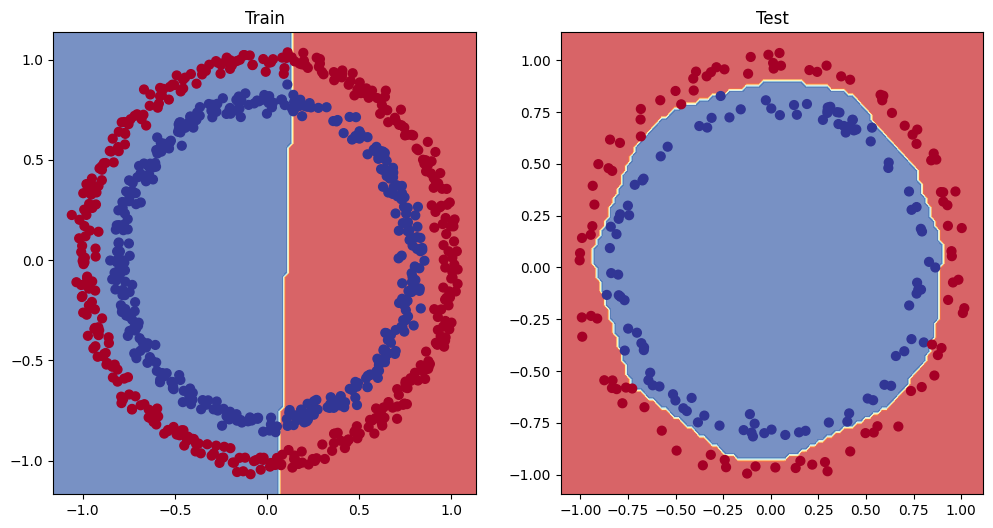

In [160]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

wow now the classification looks amazing!!!

## Replicating non-linear activation function

Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear & non-linear functions.

In [135]:
a = torch.arange(-10,10, dtype=torch.float32)
a

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

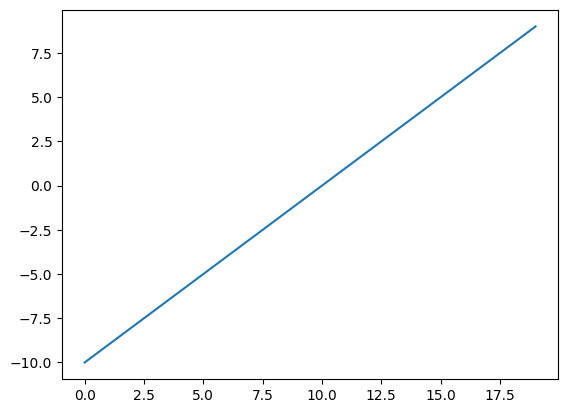

In [136]:
plt.plot(a);

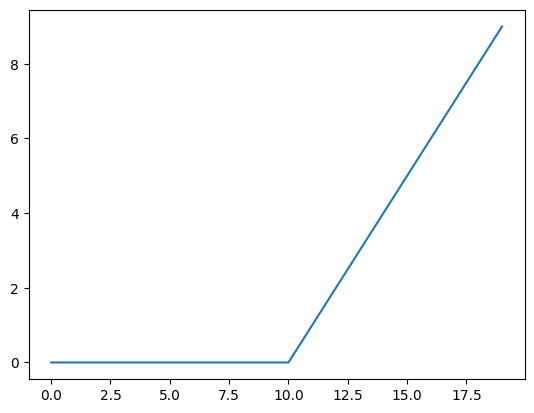

In [137]:
plt.plot(torch.relu(a));

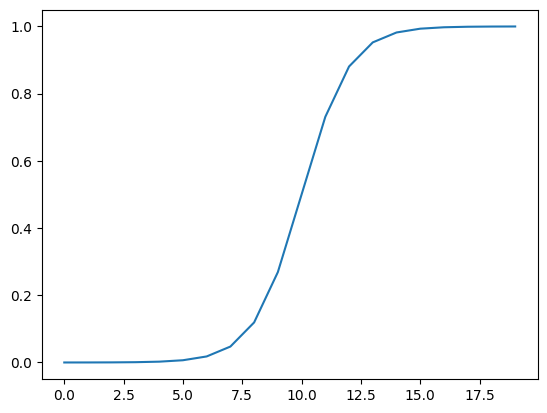

In [138]:
plt.plot(torch.sigmoid(a));

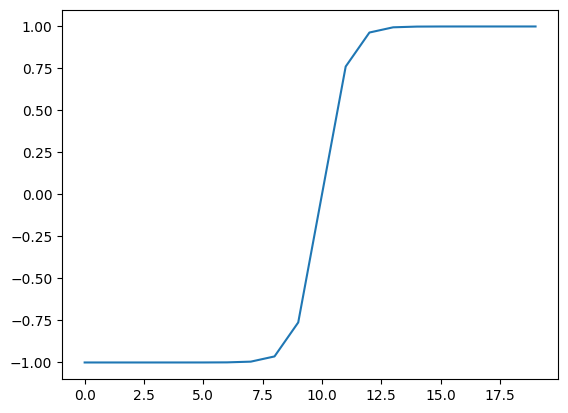

In [139]:
plt.plot(torch.tanh(a));

## Putting it all together with a multi-class classification problem
* Binary classification = one thing or another (cat vs. dog, spam vs. not spam, fraud or not fraud)
* Multi-class classification = more than one thing or another (cat vs. dog vs. chicken)

## creating a toy multi-class classification

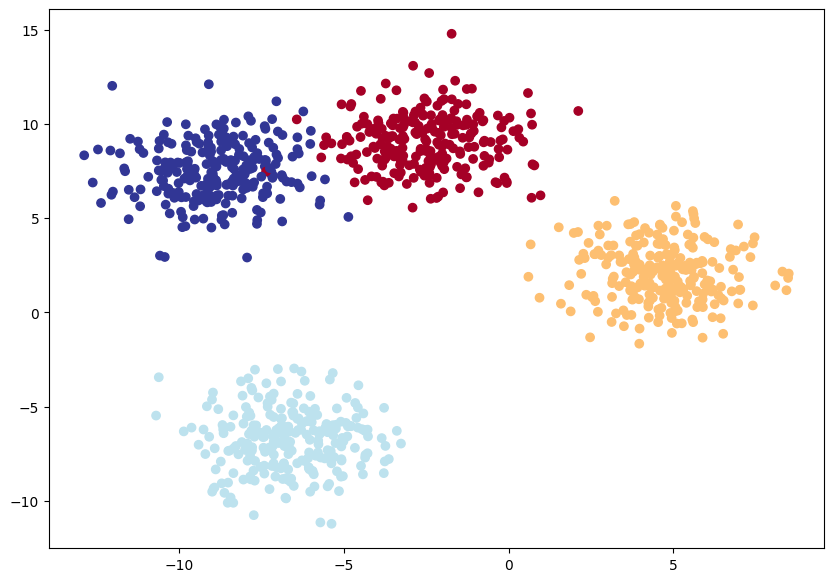

In [140]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

#data paramaters
NUM_FEATURES = 2
NUM_CLASSES = 4
RANDOM_SEED = 42

#CREATING data
X_blob, y_blob = make_blobs(n_samples = 1000,
                           n_features = NUM_FEATURES,
                           centers = NUM_CLASSES,
                           cluster_std=1.5,
                           random_state = RANDOM_SEED)
#turn data into tensor
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

#Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)
#plot
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1], c=y_blob, cmap= plt.cm.RdYlBu)


## Building a multi-class classification model in PyTorch

In [141]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
         nn.Linear(in_features=input_features, out_features=hidden_units),
         nn.Linear(in_features=hidden_units, out_features=hidden_units),
         nn.Linear(in_features=hidden_units, out_features=output_features)
  )

  def forward(self, x):
    return self.linear_layer_stack(x)

model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8)

model_4


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [142]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [143]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

##creating a loss function and optimizer

In [144]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.01)

##Getting prediction probabilities for a multi-class PyTorch model

In [145]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_logits[:10]


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]])

In [146]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [147]:
# Convert our model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]])


In [148]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds


tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3])

In [149]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

## Creating a training loop and testing loop for a multi-class PyTorch model

In [150]:
torch.manual_seed(42)

epochs = 100

#put data into target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  #training
  model_4.train()
  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss = loss_fn(y_logits,y_blob_train)
  acc = accuracy_fn(y_true=y_blob_train,
                    y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits,y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test,
                    y_pred=test_pred)

 # Print out what's happenin'
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.0432, Acc: 65.50% | Test loss: 0.9634, Test acc: 71.00%
Epoch: 10 | Loss: 0.6369, Acc: 79.50% | Test loss: 0.6122, Test acc: 88.00%
Epoch: 20 | Loss: 0.4694, Acc: 97.75% | Test loss: 0.4586, Test acc: 98.00%
Epoch: 30 | Loss: 0.3734, Acc: 98.50% | Test loss: 0.3677, Test acc: 99.00%
Epoch: 40 | Loss: 0.3101, Acc: 98.62% | Test loss: 0.3066, Test acc: 99.00%
Epoch: 50 | Loss: 0.2649, Acc: 98.88% | Test loss: 0.2623, Test acc: 99.00%
Epoch: 60 | Loss: 0.2308, Acc: 98.88% | Test loss: 0.2285, Test acc: 99.50%
Epoch: 70 | Loss: 0.2043, Acc: 99.12% | Test loss: 0.2020, Test acc: 99.50%
Epoch: 80 | Loss: 0.1831, Acc: 99.12% | Test loss: 0.1806, Test acc: 99.00%
Epoch: 90 | Loss: 0.1658, Acc: 99.12% | Test loss: 0.1630, Test acc: 99.00%


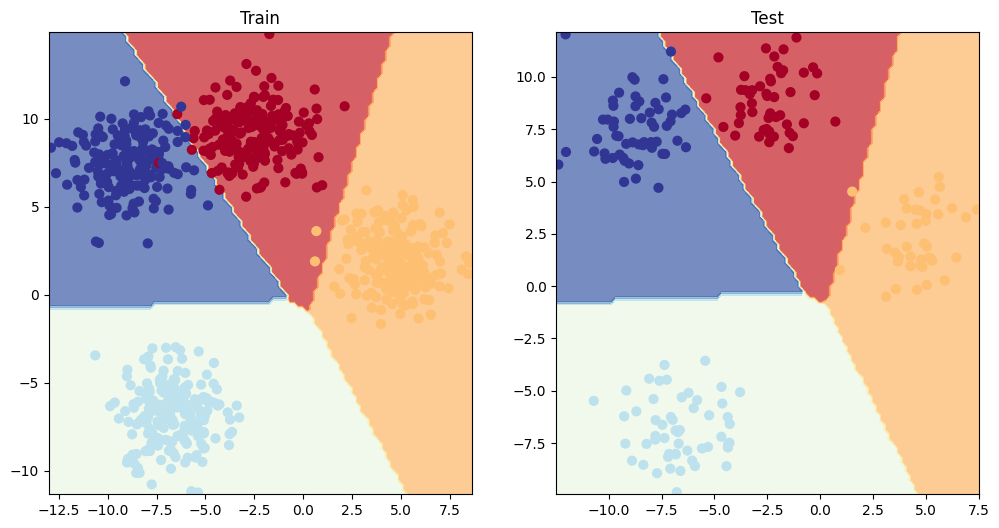

In [151]:
#visualize the classification
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

###to evaluate our classification model there are few classification metrics they are:

* Accuracy - out of 100 samples, how many does our model get right?
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

In [152]:
!pip install torchmetrics

In [153]:
from torchmetrics import Accuracy

accuracy = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)
accuracy.reset()
acc = accuracy(y_pred, y_blob_train)
print(acc.item() * 100)


99.12499785423279


*finally completed the classification in nn :)*